# Análise Exploratória da Qualidade do Ar (EPA) - New York (2025)

## Introdução

Este notebook apresenta uma análise exploratória dos dados de qualidade do ar da cidade de **New York**, no ano de **2025**, utilizando dados públicos da **EPA (Environmental Protection Agency)**.

A base utilizada é a **Daily Summary Data**, disponível em: https://aqs.epa.gov/aqsweb/airdata/download_files.html

Nesta análise, a sigla **AQI** significa **Air Quality Index** (**Índice de Qualidade do Ar**).

Objetivos desta análise:
- Carregar e preparar os dados
- Explorar estatísticas descritivas do AQI (Índice de Qualidade do Ar)
- Comparar comportamento do índice ao longo do tempo
- Visualizar tendências ao longo do tempo


In [ ]:
# Importação das bibliotecas principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


## Carregamento dos dados

Nesta etapa, vamos ler o arquivo CSV diretamente de dentro do arquivo ZIP.


In [ ]:
# Caminho do arquivo ZIP
caminho_zip = r'C:\\Users\\Guilherme_Zanini\\Desktop\\Pos-unisinos\\Introducao_a_python\\daily_44201_2025.zip'

# Leitura do CSV dentro do ZIP
df = pd.read_csv(caminho_zip, compression='zip')

# Padronização dos nomes das colunas para facilitar a análise
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_', regex=False)
)

df.head()


C:\Users\Guilherme_Zanini\AppData\Local\Temp\ipykernel_38616\2416796137.py:5: DtypeWarning: Columns (0: Event Type) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(caminho_zip, compression='zip')


,state_code,county_code,site_num,parameter_code,poc,latitude,longitude,datum,parameter_name,sample_duration,...,aqi,method_code,method_name,local_site_name,address,state_name,county_name,city_name,cbsa_name,date_of_last_change
0,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,...,6.0,87,INSTRUMENTAL - ULTRA VIOLET ABSORPTION,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2025-10-29
1,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,...,61.0,87,INSTRUMENTAL - ULTRA VIOLET ABSORPTION,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2025-10-29
2,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,...,44.0,87,INSTRUMENTAL - ULTRA VIOLET ABSORPTION,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2025-10-29
3,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,...,44.0,87,INSTRUMENTAL - ULTRA VIOLET ABSORPTION,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2025-10-29
4,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,...,45.0,87,INSTRUMENTAL - ULTRA VIOLET ABSORPTION,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2025-10-29


In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 249474 entries, 0 to 249473
Data columns (total 29 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   state_code           249474 non-null  int64  
 1   county_code          249474 non-null  int64  
 2   site_num             249474 non-null  int64  
 3   parameter_code       249474 non-null  int64  
 4   poc                  249474 non-null  int64  
 5   latitude             249474 non-null  float64
 6   longitude            249474 non-null  float64
 7   datum                249474 non-null  str    
 8   parameter_name       249474 non-null  str    
 9   sample_duration      249474 non-null  str    
 10  pollutant_standard   249474 non-null  str    
 11  date_local           249474 non-null  str    
 12  units_of_measure     249474 non-null  str    
 13  event_type           2572 non-null    str    
 14  observation_count    249474 non-null  int64  
 15  observation_percent  249474 

In [ ]:
df.shape


(249474, 29)

## Tratamento dos dados

Passos:
- Converter `date_local` para datetime
- Verificar e tratar valores nulos
- Filtrar apenas New York
- Selecionar colunas relevantes para a análise


In [ ]:
df['date_local'] = pd.to_datetime(df['date_local'], errors='coerce')
colunas_principais = ['date_local', 'state_name', 'city_name', 'parameter_name', 'aqi', 'arithmetic_mean']
df[colunas_principais].isnull().sum()


date_local         0
state_name         0
city_name          0
parameter_name     0
aqi                1
arithmetic_mean    0
dtype: int64

In [ ]:
df_limpo = df.dropna(subset=['date_local', 'city_name', 'parameter_name', 'aqi'])
df_ny = df_limpo[df_limpo['city_name'].str.upper() == 'NEW YORK'].copy()
colunas_relevantes = ['date_local', 'state_name', 'county_name', 'city_name', 'parameter_name', 'sample_duration', 'aqi', 'arithmetic_mean', '1st_max_value', 'units_of_measure']
df_ny = df_ny[colunas_relevantes]
print('Dimensão após limpeza e filtro:', df_ny.shape)
df_ny.head()


Dimensão após limpeza e filtro: (1130, 10)


,date_local,state_name,county_name,city_name,parameter_name,sample_duration,aqi,arithmetic_mean,1st_max_value,units_of_measure
156368,2025-03-31,New York,Bronx,New York,Ozone,8-HR RUN AVG BEGIN HOUR,25.0,0.026500,0.027,Parts per million
156369,2025-04-01,New York,Bronx,New York,Ozone,8-HR RUN AVG BEGIN HOUR,38.0,0.038529,0.041,Parts per million
156370,2025-04-02,New York,Bronx,New York,Ozone,8-HR RUN AVG BEGIN HOUR,36.0,0.035059,0.039,Parts per million
156371,2025-04-03,New York,Bronx,New York,Ozone,8-HR RUN AVG BEGIN HOUR,19.0,0.015059,0.021,Parts per million
156372,2025-04-04,New York,Bronx,New York,Ozone,8-HR RUN AVG BEGIN HOUR,35.0,0.033647,0.038,Parts per million


## Exploração e estatística descritiva


In [ ]:
df_ny['aqi'].describe()


count    1130.000000
mean       40.981416
std        18.026961
min         6.000000
25%        31.000000
50%        37.000000
75%        44.000000
max       154.000000
Name: aqi, dtype: float64

In [ ]:
media_aqi = df_ny['aqi'].mean()
mediana_aqi = df_ny['aqi'].median()
desvio_padrao_aqi = df_ny['aqi'].std()
min_aqi = df_ny['aqi'].min()
max_aqi = df_ny['aqi'].max()
quartis_aqi = df_ny['aqi'].quantile([0.25, 0.50, 0.75])
print(f'Média AQI: {media_aqi:.2f}')
print(f'Mediana AQI: {mediana_aqi:.2f}')
print(f'Desvio padrão AQI: {desvio_padrao_aqi:.2f}')
print(f'Mínimo AQI: {min_aqi}')
print(f'Máximo AQI: {max_aqi}')
print('Quartis AQI:')
print(quartis_aqi)


Média AQI: 40.98
Mediana AQI: 37.00
Desvio padrão AQI: 18.03
Mínimo AQI: 6.0
Máximo AQI: 154.0
Quartis AQI:
0.25    31.0
0.50    37.0
0.75    44.0
Name: aqi, dtype: float64


In [ ]:
df_ny['parameter_name'].value_counts()


parameter_name
Ozone    1130
Name: count, dtype: int64

In [ ]:
aqi_medio_poluente = df_ny.groupby('parameter_name')['aqi'].mean().sort_values(ascending=False)
aqi_medio_poluente


parameter_name
Ozone    40.981416
Name: aqi, dtype: float64

## Visualizações


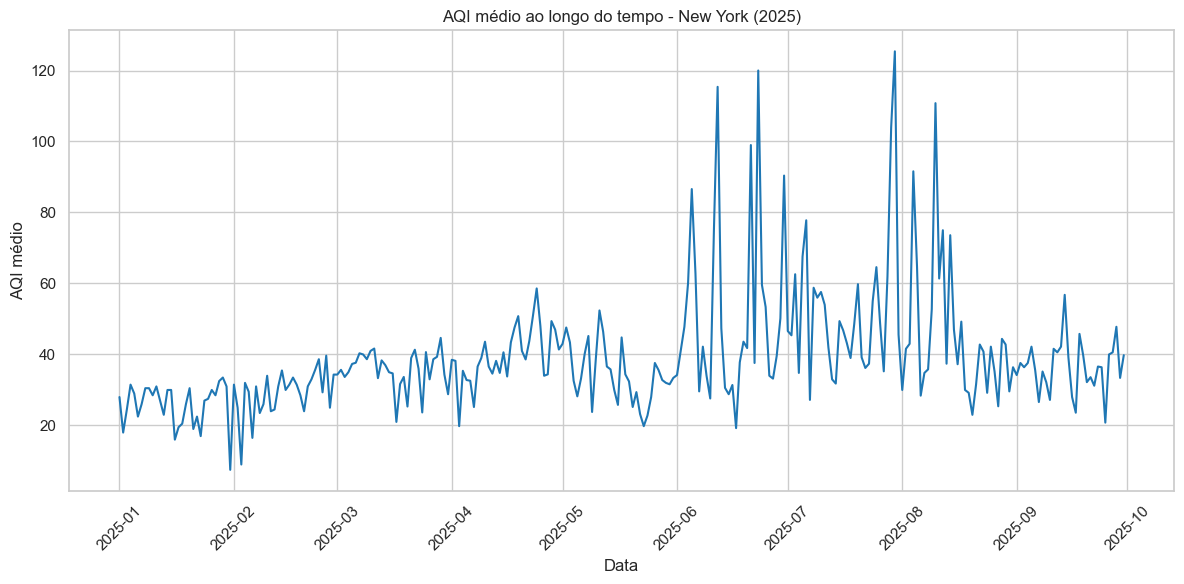

In [ ]:
aqi_tempo = df_ny.groupby('date_local')['aqi'].mean().reset_index()
plt.figure()
sns.lineplot(data=aqi_tempo, x='date_local', y='aqi', color='tab:blue')
plt.title('AQI médio ao longo do tempo - New York (2025)')
plt.xlabel('Data')
plt.ylabel('AQI médio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


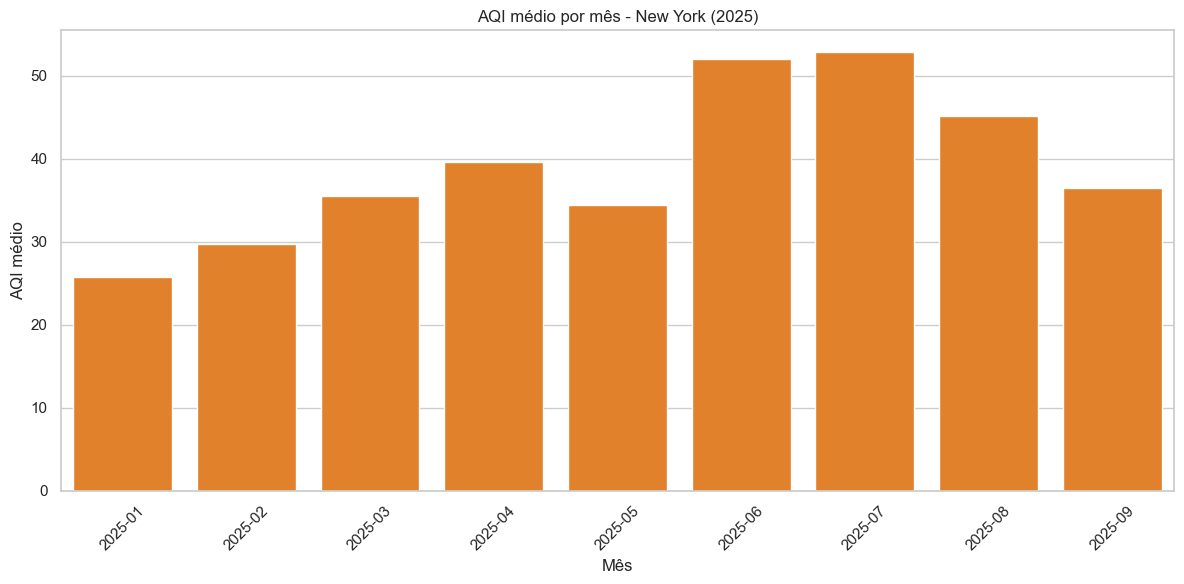

In [ ]:
# Gráfico 2: Barras - AQI médio por mês
df_ny['mes'] = df_ny['date_local'].dt.to_period('M').astype(str)
aqi_medio_mes = df_ny.groupby('mes')['aqi'].mean().reset_index()

plt.figure()
sns.barplot(data=aqi_medio_mes, x='mes', y='aqi', color='tab:orange')
plt.title('AQI médio por mês - New York (2025)')
plt.xlabel('Mês')
plt.ylabel('AQI médio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


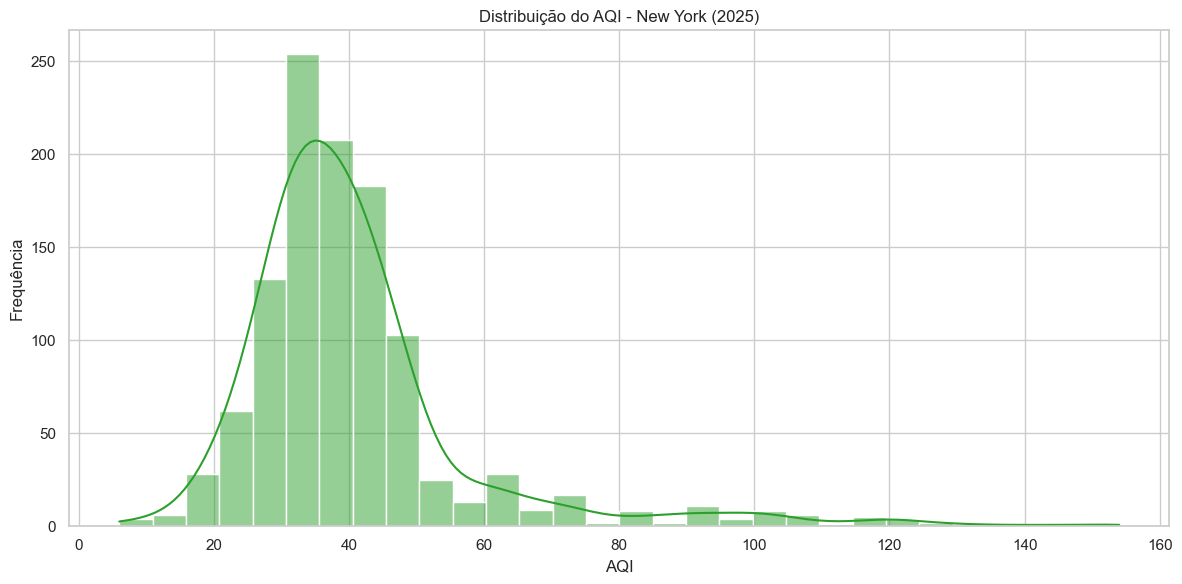

In [ ]:
plt.figure()
sns.histplot(df_ny['aqi'], bins=30, kde=True, color='tab:green')
plt.title('Distribuição do AQI - New York (2025)')
plt.xlabel('AQI')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()


## Interpretação dos gráficos

- **AQI (Índice de Qualidade do Ar) ao longo do tempo:** observamos aumento do índice do início do ano até o verão, com os maiores picos em 30/07/2025 (125,4), 23/06/2025 (120,0) e 12/06/2025 (115,4).
- **AQI médio por mês:** os maiores valores médios aparecem em junho e julho, piora sazonal da qualidade do ar no meio do ano.
- **Distribuição do AQI:** a distribuição concentra-se em valores moderados (mediana 37, Q1 31, Q3 44), mas com cauda à direita, indicando poucos dias com índice muito alto (máximo 154).

Leitura geral: a qualidade do ar em New York em 2025 foi, na maior parte do tempo moderada para ozônio, com episódios pontuais de piora mais forte no período de verão.


## Conclusão

A análise exploratória com dados da EPA para New York (2025) mostrou um AQI (Índice de Qualidade do Ar) médio de 40,98, mediana 37, desvio padrão 18,03, mínimo 6 e máximo 154 para o poluente analisado.

Principais achados:
- Houve aumento do índice ao longo dos meses, com valores mais altos no meio do ano (especialmente junho e julho).
- Existem dias extremos de pior qualidade do ar, embora a maior parte dos dias esteja em uma faixa intermediária do índice.
- O arquivo utilizado (`daily_44201_2025`) representa medições de ozônio, portanto a análise por poluente ficou concentrada nesse parâmetro.
- O AQI é um indicador resumido da qualidade do ar e pode ser complementado por variáveis meteorológicas e por comparação com outros anos.
